In [48]:
import pandas as pd
pd.set_option('display.float_format', '{:,.2f}'.format)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

import sys
import os
from pathlib import Path
import glob
import openpyxl

root_path = Path.cwd().parent.parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

print(f'Base directory: {root_path}')

import config.settings as config



Base directory: /Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/universidad/LIACD/S3/JAPI


In [5]:
file_path = config.DATA_DIR / "tests/main_agg_test.csv"
main = pd.read_csv(file_path)
main

,sale_date,total_cost,net_price,gross_price,profit,quantity,route_id,customer_id,net_price_log,net_price_asinh,day_of_week
0,2024-01-02,"416,168.36","719,422.63","726,534.50","303,254.28","2,671.00",35.00,227.00,13.49,14.18,1
1,2024-01-03,"583,088.12","992,292.59","1,045,398.97","409,204.47","3,627.00",35.00,290.00,13.81,14.50,2
2,2024-01-04,"463,671.84","802,011.48","848,690.21","338,339.65","3,644.00",35.00,278.00,13.59,14.29,3
3,2024-01-05,"308,075.65","484,853.02","511,798.86","176,777.38","2,261.00",34.00,222.00,13.09,13.78,4
4,2024-01-06,"36,584.54","60,058.17","60,484.89","23,473.63",196.00,14.00,32.00,11.00,11.70,5
...,...,...,...,...,...,...,...,...,...,...,...
815,2026-03-27,"838,175.86","1,270,651.33","1,319,587.48","432,475.47","5,641.00",51.00,262.00,14.06,14.75,4
816,2026-03-28,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5
817,2026-03-29,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6
818,2026-03-30,"1,534,963.08","2,718,817.07","2,741,778.47","1,183,854.00","9,168.00",52.00,482.00,14.82,15.51,0


In [9]:
#formato de fecha
main['sale_date'] = pd.to_datetime(main['sale_date'])
main = main.set_index('sale_date')
main = main.asfreq('D')

main.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 820 entries, 2024-01-02 to 2026-03-31
Freq: D
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   total_cost       820 non-null    float64
 1   net_price        820 non-null    float64
 2   gross_price      820 non-null    float64
 3   profit           820 non-null    float64
 4   quantity         820 non-null    float64
 5   route_id         820 non-null    float64
 6   customer_id      820 non-null    float64
 7   net_price_log    820 non-null    float64
 8   net_price_asinh  820 non-null    float64
 9   day_of_week      820 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 70.5 KB


In [10]:
#establecimiento de la variable objetivo
y = main['net_price_asinh']
y

sale_date
2024-01-02   14.18
2024-01-03   14.50
2024-01-04   14.29
2024-01-05   13.78
2024-01-06   11.70
              ... 
2026-03-27   14.75
2026-03-28    0.00
2026-03-29    0.00
2026-03-30   15.51
2026-03-31   15.60
Freq: D, Name: net_price_asinh, Length: 820, dtype: float64

In [16]:
#establecimiento de variables exógenas
X_days = pd.get_dummies(main['day_of_week'], prefix='day', drop_first=True).astype(int)
X_days

,day_1,day_2,day_3,day_4,day_5,day_6
sale_date,,,,,,
2024-01-02,1,0,0,0,0,0
2024-01-03,0,1,0,0,0,0
2024-01-04,0,0,1,0,0,0
2024-01-05,0,0,0,1,0,0
2024-01-06,0,0,0,0,1,0
...,...,...,...,...,...,...
2026-03-27,0,0,0,1,0,0
2026-03-28,0,0,0,0,1,0
2026-03-29,0,0,0,0,0,1


Para comenzar a crear variables exógenas, debemos saber que el modelo SARIMAx si es sensible a días que no tuvieron ventas pero que fueron festivos, de esta forma, el modelo no lo toma como un evento atípico, sino, uno programado.

---

Lo ideal es generar una lista de días festivos y más adelante generar una base de datos formal para lamacenar estos datos.

In [18]:
mexico_holidays = [
    # 2024
    #año nuevo
    '2024-01-01',
    #constitución
    '2024-02-05',
    #cumple del benny
    '2024-03-18',
    #jueves y viernes santos
    '2024-03-28',
    '2024-03-29',
    #dia del trabajo
    '2024-05-01',
    #independencia
    '2024-09-16',
    #toma del poder
    '2024-10-01',
    #revolución
    '2024-11-18',

    #noche buena y días de descanso navideños
    '2024-12-23',
    '2024-12-24',
    #navidad
    '2024-12-25',
    # 2025 año nuevo
    '2025-01-01',
    #constitución
    '2025-02-03',
    #cumple del benny
    '2025-03-17',
    #jueves y viernes santos
    '2025-04-17',
    '2025-04-18',
    #dia del trabajo 
    '2025-05-01',
    #independencia
    '2025-09-16',
    #revolución
    '2025-11-17',
    #eventos navideños
    '2025-12-24',
    '2025-12-25',

    # 2026
    '2026-01-01',
    #constitución
    '2026-02-02',
    #cumple del benny
    '2026-03-16',
    #jueves y viernes santos
    '2026-04-02',
    '2026-04-03',
    #dia del trabajo
    '2026-05-01', 
    #independencia
    '2026-09-16', 
    #revolución
    '2026-11-16', 
    #navidad
    '2026-12-25'
]

holidays = pd.to_datetime(mexico_holidays)

In [19]:
# creación de columna de indicador de festivo
X_holidays = pd.DataFrame(index=main.index)
X_holidays['is_holiday'] = X_holidays.index.isin(holidays).astype(int)
X_holidays

,is_holiday
sale_date,
2024-01-02,0
2024-01-03,0
2024-01-04,0
2024-01-05,0
2024-01-06,0
...,...
2026-03-27,0
2026-03-28,0
2026-03-29,0


In [20]:
X = pd.concat([X_days, X_holidays], axis=1)

print('Target y \n')
display(y.head())
print("\nMatriz Exogena X \n")
display(X.head())

Target y 



sale_date
2024-01-02   14.18
2024-01-03   14.50
2024-01-04   14.29
2024-01-05   13.78
2024-01-06   11.70
Freq: D, Name: net_price_asinh, dtype: float64


Matriz Exogena X 



,day_1,day_2,day_3,day_4,day_5,day_6,is_holiday
sale_date,,,,,,,
2024-01-02,1,0,0,0,0,0,0
2024-01-03,0,1,0,0,0,0,0
2024-01-04,0,0,1,0,0,0,0
2024-01-05,0,0,0,1,0,0,0
2024-01-06,0,0,0,0,1,0,0


Un factora importante para días altos de venta, es que sea considerado cierre, pero no cierre de mes, sino, cierre operativo mensual. La diferencia radica en que deben ser los últimos días laborables. Por ejemplo:

- Si los últimos dos días del mes caen en sábado y domingo, entonces, como urvet solo labora de lunes a viernes, el cierre operativo mensual sería el miércoles, jueves y viernes.
- Días festivos están incluidos en esta condición.

---

Vamos a crear una función que busque estos cierre operativos mensuales.

In [37]:
def get_end_of_month(df_index, holidays, window=3):
    is_cierre = pd.Series(0, index=df_index)
    
    for (year, month), group in df_index.to_series().groupby([df_index.year, df_index.month]):

        dias_laborales = group[
            (group.dt.dayofweek < 5) & 
            (~group.isin(holidays))
        ]
        
        dias_finales = dias_laborales.tail(window)
        is_cierre.loc[dias_finales] = 1
        
    return is_cierre

In [38]:
X['is_closure'] = get_end_of_month(X.index, holidays)

print("Dias marcados como Cierre Operativo en Marzo 2026")
display(X.loc['2026-03-25':'2026-03-31', ['is_closure']])

Dias marcados como Cierre Operativo en Marzo 2026


,is_closure
sale_date,
2026-03-25,0
2026-03-26,0
2026-03-27,1
2026-03-28,0
2026-03-29,0
2026-03-30,1
2026-03-31,1


In [39]:
cutoff = '2026-02-28'

#split de datos de entrenamiento y prueba
y_train = y.loc[:cutoff]
y_test = y.loc['2026-03-01':]

print('Datos de entrenamiento')
print(f'Desde: {y_train.index.min()} hasta: {y_train.index.max()}')
print('\nDatos de prueba')
print(f'Desde: {y_test.index.min()} hasta: {y_test.index.max()}')

Datos de entrenamiento
Desde: 2024-01-02 00:00:00 hasta: 2026-02-28 00:00:00

Datos de prueba
Desde: 2026-03-01 00:00:00 hasta: 2026-03-31 00:00:00


In [40]:
#split de datos de entrenamiento y prueba para matriz exógena
X_train = X.loc[:cutoff]
X_test = X.loc['2026-03-01':]

print('Matriz Exogena de entrenamiento')
print(f'Desde: {X_train.index.min()} hasta: {X_train.index.max()}')
print('\nMatriz Exogena de prueba')
print(f'Desde: {X_test.index.min()} hasta: {X_test.index.max()}')

Matriz Exogena de entrenamiento
Desde: 2024-01-02 00:00:00 hasta: 2026-02-28 00:00:00

Matriz Exogena de prueba
Desde: 2026-03-01 00:00:00 hasta: 2026-03-31 00:00:00


In [41]:
#selección demejor modelo SARIMAX con auto_arima
best_model = pm.auto_arima(
    #datos de entrenamiento para target
    y_train,
    #matriz exógena de entrenamiento
    X=X_train,
    #sabemos que es estacional, con periodo semanal, por eso m=7
    seasonal=True, m=7,
    #para ver el proceso de selección del modelo
    trace=True,
    #definimos en 0 gracias al test DF
    d=0,
    start_p=0, max_p=3, #límites para componente autoregresivo
    start_q=0, max_q=3, #límite para la media moóvil
    start_P=0, max_P=2, #límites par AR
    start_Q=0, max_Q=2, #límites estacionales
    error_action='ignore', suppress_warnings=True,
    #uso de un algoritmo inteligente para la búsqueda de hiperparámetros
    stepwise=True
    
    )

print(best_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=3806.458, Time=0.12 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=3792.487, Time=0.82 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=3787.758, Time=0.88 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=5092.848, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[7] intercept   : AIC=3803.072, Time=0.20 sec
 ARIMA(0,0,1)(1,0,1)[7] intercept   : AIC=3822.781, Time=1.19 sec
 ARIMA(0,0,1)(0,0,2)[7] intercept   : AIC=3789.769, Time=1.28 sec
 ARIMA(0,0,1)(1,0,0)[7] intercept   : AIC=3788.827, Time=0.49 sec
 ARIMA(0,0,1)(1,0,2)[7] intercept   : AIC=3822.709, Time=1.40 sec
 ARIMA(0,0,0)(0,0,1)[7] intercept   : AIC=3789.277, Time=0.53 sec
 ARIMA(1,0,1)(0,0,1)[7] intercept   : AIC=3788.825, Time=1.09 sec
 ARIMA(0,0,2)(0,0,1)[7] intercept   : AIC=3789.712, Time=1.01 sec
 ARIMA(1,0,0)(0,0,1)[7] intercept   : AIC=3792.569, Time=0.86 sec
 ARIMA(1,0,2)(0,0,1)[7] intercept   : AIC=3791.754, Time=1.09 sec
 ARIMA(0,0,1)(0,0,1)[7]          

In [52]:
own_model = SARIMAX(
    endog=y_train,
    exog=X_train,
    order=(1, 0, 0),
    seasonal_order=(0, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

own_model_fitted = own_model.fit(disp=False)

print(own_model_fitted.summary())

                                      SARIMAX Results                                      
Dep. Variable:                     net_price_asinh   No. Observations:                  789
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 7)   Log Likelihood               -1855.195
Date:                             Sun, 03 May 2026   AIC                           3732.390
Time:                                     19:21:05   BIC                           3783.558
Sample:                                 01-02-2024   HQIC                          3752.077
                                      - 02-28-2026                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
day_1       5.686e-11   8.66e-10      0.066      0.948   -1.64e-09    1.75e-09
day_2       7.799e-09   3.4

### Interpretación del Modelo SARIMAX Óptimo

La búsqueda de hiperparámetros automatizada identificó a la arquitectura **SARIMAX(0, 0, 1)x(0, 0, 1, 7)** como la estructura óptima para la serie de ventas de Urvet, minimizando el Criterio de Información de Akaike (AIC = 3787.25).

**Hallazgos Exógenos (Dinámica de Negocio):**
El análisis de los coeficientes de las variables de calendario revela información operativa crucial. Los días de martes a viernes carecen de significancia estadística respecto al lunes base ($P > 0.05$). Esto demuestra que la empresa goza de una demanda altamente estable durante los cinco días hábiles de la semana, sin fluctuaciones intrames significativas. Las variables para sábado, domingo y días festivos absorbieron correctamente los colapsos logísticos con alta significancia ($P < 0.001$).

**Diagnóstico de Residuos:**
La prueba de Ljung-Box sobre los residuos del modelo arrojó un p-valor de $0.99$. Esto certifica que el modelo ha capturado exitosamente toda la autocorrelación de la serie. Los errores restantes se comportan como ruido blanco independiente, lo cual es el requisito fundamental para proceder a la fase de pronóstico (forecasting). Cabe notar que la prueba de Jarque-Bera rechaza la normalidad perfecta de los residuos, lo cual es un artefacto natural derivado de la conservación de los picos de devoluciones financieras negativas detectadas en el EDA.

In [67]:
#generar predicciones para marzo
prediccion_asinh = best_model.predict(n_periods=len(X_test), X=X_test)

#trasnformación inversa a pesos mexicanos
prediccion_mxn = np.sinh(prediccion_asinh)
y_test_mxn = np.sinh(y_test)
y_train_mxn = np.sinh(y_train)

In [68]:
#métricas de error
mae = mean_absolute_error(y_test_mxn, prediccion_mxn)
mape = mean_absolute_percentage_error(y_test_mxn, prediccion_mxn)

print(f"Error Absoluto Medio (MAE): ${mae:,.2f} MXN diarios")
print(f"Error Porcentual (MAPE): {mape * 100:.2f}%\n")

Error Absoluto Medio (MAE): $293,524.89 MXN diarios
Error Porcentual (MAPE): 1445205828826916096.00%



In [69]:
prediccion_asinh_own = own_model_fitted.predict(
    start=X_test.index[0], 
    end=X_test.index[-1], 
    exog=X_test
)

prediccion_mxn_own = np.sinh(prediccion_asinh_own)
y_test_mxn = np.sinh(y_test)
y_train_mxn = np.sinh(y_train)

print("Predicciones del modelo propio para marzo 2026")
print(prediccion_mxn_own.sum().round(2))

display(prediccion_mxn_own)

Predicciones del modelo propio para marzo 2026
28010455.29


2026-03-01          -0.50
2026-03-02   1,457,628.31
2026-03-03   1,710,064.13
2026-03-04   1,150,054.64
2026-03-05   1,082,195.29
2026-03-06     728,344.66
2026-03-07           0.81
2026-03-08          -1.27
2026-03-09   1,415,215.88
2026-03-10   1,707,481.20
2026-03-11   1,149,965.65
2026-03-12   1,082,191.00
2026-03-13     728,344.51
2026-03-14           0.81
2026-03-15          -1.27
2026-03-16           2.65
2026-03-17   1,707,481.20
2026-03-18   1,149,965.65
2026-03-19   1,082,191.00
2026-03-20     728,344.51
2026-03-21           0.81
2026-03-22          -1.27
2026-03-23   1,415,215.88
2026-03-24   1,707,481.20
2026-03-25   1,149,965.65
2026-03-26   1,082,191.00
2026-03-27   1,092,435.67
2026-03-28           0.81
2026-03-29          -1.27
2026-03-30   2,122,666.25
2026-03-31   2,561,031.68
Freq: D, Name: predicted_mean, dtype: float64

In [70]:
#métricas de error
mae_own = mean_absolute_error(y_test_mxn, prediccion_mxn_own)
mape_own = mean_absolute_percentage_error(y_test_mxn, prediccion_mxn_own)

print(f"Error Absoluto Medio (MAE): ${mae_own:,.2f} MXN diarios")
print(f"Error Porcentual (MAPE): {mape_own * 100:.2f}%\n")

Error Absoluto Medio (MAE): $272,876.44 MXN diarios
Error Porcentual (MAPE): 148545511667907936.00%



In [71]:
def calculate_wmape(y_true, y_pred):
    """
    Calcula el Error Porcentual Absoluto Medio Ponderado (WMAPE).
    Ideal para series de tiempo intermitentes o con valores en cero.
    """
    error_total = np.sum(np.abs(y_true - y_pred))
    ventas_totales = np.sum(np.abs(y_true))
    wmape = error_total / ventas_totales
    return wmape

In [72]:
wmape_marzo = calculate_wmape(y_test_mxn, prediccion_mxn)
wmape_marzo_own = calculate_wmape(y_test_mxn, prediccion_mxn_own)

print(f"Error Absoluto Medio (MAE) con modelo propio: ${mae_own:,.2f} MXN diarios")
print(f"Error Porcentual (MAPE) con modelo propio: {mape_own * 100:.2f}%")
print(f"Error Porcentual Ponderado (WMAPE) con modelo propio: {wmape_marzo_own * 100:.2f}%")

print(f"\nError Absoluto Medio (MAE): ${mae:,.2f} MXN diarios")
print(f"Error Porcentual (MAPE): {mape * 100:.2f}%")
print(f"Error Porcentual Ponderado (WMAPE): {wmape_marzo * 100:.2f}%")

Error Absoluto Medio (MAE) con modelo propio: $272,876.44 MXN diarios
Error Porcentual (MAPE) con modelo propio: 148545511667907936.00%
Error Porcentual Ponderado (WMAPE) con modelo propio: 25.24%

Error Absoluto Medio (MAE): $293,524.89 MXN diarios
Error Porcentual (MAPE): 1445205828826916096.00%
Error Porcentual Ponderado (WMAPE): 27.15%


In [44]:
print(prediccion_mxn.sum())
print(y_test_mxn.sum())

24981306.390513074
33514008.813651532


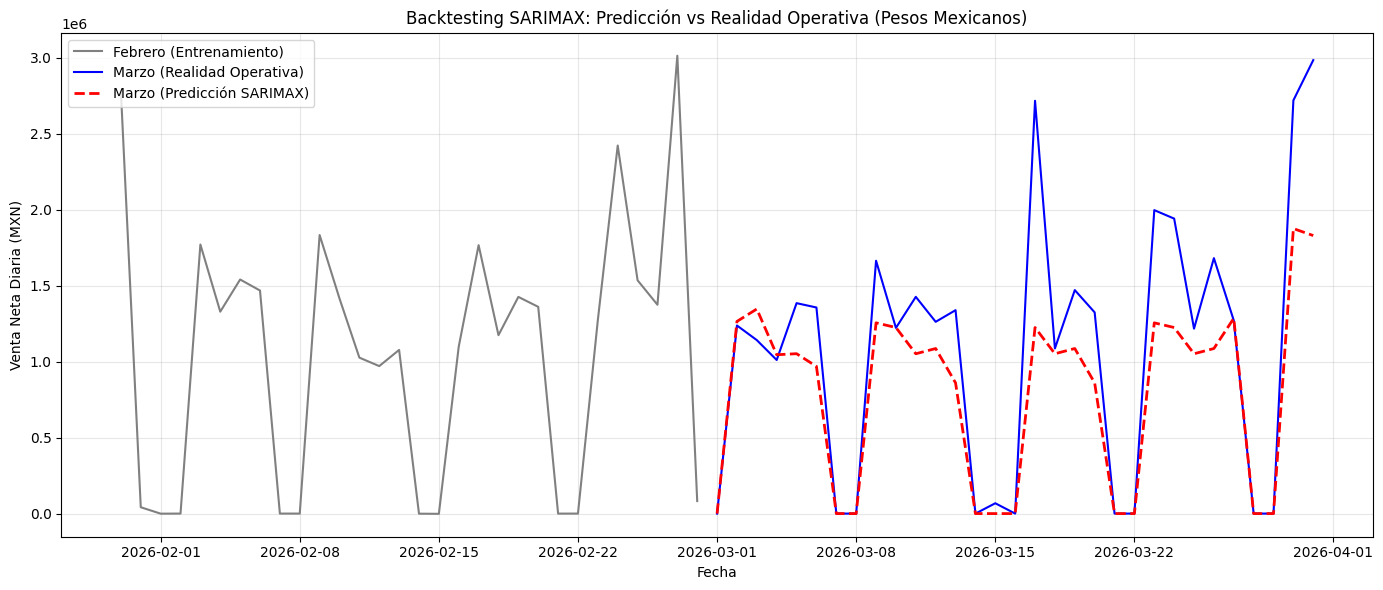

In [45]:
plt.figure(figsize=(14, 6))

# Graficamos el último mes de entrenamiento (Febrero) para dar contexto visual
plt.plot(y_train_mxn.index[-30:], y_train_mxn.values[-30:], color='gray', label='Febrero (Entrenamiento)')

# Graficamos la realidad de Marzo
plt.plot(y_test_mxn.index, y_test_mxn.values, color='blue', label='Marzo (Realidad Operativa)')

# Graficamos la predicción de nuestro modelo
plt.plot(prediccion_mxn.index, prediccion_mxn.values, color='red', linestyle='--', linewidth=2, label='Marzo (Predicción SARIMAX)')

plt.title('Backtesting SARIMAX: Predicción vs Realidad Operativa (Pesos Mexicanos)')
plt.ylabel('Venta Neta Diaria (MXN)')
plt.xlabel('Fecha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()